<a href="https://colab.research.google.com/github/Marcomaltoni/Advanced_deep_learning/blob/main/ICECUBE_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install awkward

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 26.9 MB/s eta 0:00:00


In [2]:
pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-t9okyh0u
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-t9okyh0u
  Resolved https://github.com/thoglu/jammy_flows.git to commit 3ec7872f8535b8e8db2e31f74a7c55bad5c54d5f
  Preparing metadata (setup.py) ... done
  Created wheel for jammy_flows: filename=jammy_flows-1.0.0-py3-none-any.whl size=174322 sha256=dff542ab50830820e87347f4f3e5dc428b95b72983820c10827bcb8d5c60dbb6
  Stored in directory: /tmp/pip-ephem-wheel-cache-w4_qmbms/wheels/c0/ce/35/60016f460c07fecc64f55db2a40862c9add349fb0620845532
Successfully built jammy_flows


In [3]:
# mount your google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/Advanced_deep_learning')

In [5]:
import time
import sys
import os
import argparse
import io
from datetime import datetime
import numpy as np
import awkward
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
import torch.nn.functional as F
from scipy.stats import norm
import jammy_flows
from torch.nn.utils.rnn import pad_sequence  # http://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


In [6]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# Useful functions for plots

In [7]:
def normalize(labels, p):
    """
    Normalize the input labels using percentile-based scaling.

    This function scales the input labels to a range of [0, 1] based on the specified percentiles.
    The scaling is done by computing the percentiles of the labels and then normalizing the labels
    using these percentile values. The percentiles are decimals, we use these boundaries as the min/max
    of the dataset could be related to very rare data due to fluctuations, we want to identify a range
    in which are contained most of the data.

    Parameters:
    labels (np.ndarray): The input labels to be normalized.
    p (float): The percentile value used for scaling. The function uses the p-th and (1-p)-th percentiles
               for normalization.

    Returns:
    tuple: A tuple containing the normalized labels and the range used for normalization.
           - normalized_labels (np.ndarray): The normalized labels.
           - ranges (np.ndarray): The range used for normalization, which includes the p-th and (1-p)-th percentiles.
    """
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

In [8]:
# Function to denormalize the labels back to their original scale
def denormalize(labels, ranges):
    """
    Denormalize the input labels using the specified range.

    This function denormalizes the input labels using the specified range values.
    The denormalization is done by scaling the labels back to the original range
    using the provided range values.

    Parameters:
        labels (np.ndarray): The normalized labels to be  denormalized.
        ranges (np.ndarray): The range values used for normalization.

    Returns:
        np.ndarray: The denormalized labels.
    """
    return labels * (ranges[1] - ranges[0]) + ranges[0]


In [9]:
def denormalize_std(uncertainty, ranges):
    """
    Denormalizes the given uncertainty predictions using the provided range.

    It is different to the denormalization of the labels which also includes a shift, as
    the uncertainty is a range and is independent from shifting.

    Parameters
    ----------
    uncertainty : array-like
        The normalized uncertainty to be denormalized.
    ranges : array-like
        A two-element array-like object where the first element is the minimum value
        and the second element is the maximum value of the original range.
    Returns
    -------
    array-like
        The denormalized uncertainty.
    """

    return uncertainty * (ranges[1] - ranges[0])

In [10]:
def plot_loss(N_epochs, train_loss, eval_loss):
  plt.figure(figsize = (10,10))
  plt.xlabel('Number of epochs')
  plt.ylabel('Loss function')
  plt.plot(range(N_epochs), train_loss, color = 'red', label = 'Training')
  plt.plot(range(N_epochs), eval_loss, color = 'green', label = 'Validation')
  plt.legend(fontsize = 10)
  plt.show()

In [11]:
def plot_results(denorm_true_labels, denorm_predictions, labels_name, denorm_std, colors):
  N_labels = denorm_true_labels.shape[1]

  fig,ax = plt.subplots(nrows = 3, ncols = N_labels, figsize = (15,18))
  ax = ax.flatten()

  min_pred = np.min([denorm_predictions[:, 0], denorm_predictions[:, 1]])
  max_pred = np.max([denorm_predictions[:, 0], denorm_predictions[:, 1]])
  min_true = np.min([denorm_true_labels[:, 0], denorm_true_labels[:, 1]])
  max_true = np.max([denorm_true_labels[:, 0], denorm_true_labels[:, 1]])

  ax[0].set_ylim(min_pred, max_pred)
  ax[1].set_ylim(min_pred, max_pred)
  ax[0].set_xlim(min_true, max_true)
  ax[1].set_xlim(min_true, max_true)

  for i in range(N_labels):
    ax[i].set_xlabel('Real Data')
    ax[i].set_ylabel('Prediction')
    ax[i].set_title(labels_name[i])
    ax[i].scatter(denorm_true_labels[:,i],denorm_predictions[:,i], color = colors[i], s = 10, label = 'data')
    ax[i].axline((denorm_true_labels[:,i].min(), denorm_true_labels[:,i].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
    ax[i].legend(fontsize = 10)

  for i in range(N_labels,N_labels*2):
    ax[i].set_xlabel('Uncertainty values')
    ax[i].set_ylabel('Entries')
    ax[i].hist(denorm_std[:,0], bins = 50, color = colors[i-2])

  pull_val = (denorm_predictions - denorm_true_labels)/denorm_std

  for i in range(N_labels*2, N_labels*3):
    counts, bin_edges = np.histogram(pull_val[:,i-4], bins=50,range = (-5,5), density=True) #Obtain counts for the bins and bin limits for the gaussian fits of the histograms
    mu, std = norm.fit(pull_val[:,i-4]) #Built in function for gaussian fit of data, computes their mean and standard deviation
    x_range = np.linspace(bin_edges[0], bin_edges[-1], 100) #Define an arbitrary x_range to plot the fitted curve
    curve_fit = norm.pdf(x_range, mu, std) #Define points distributed on the computed gaussian for the defined range

    ax[i].hist(pull_val[:,i-4], bins=50, density=True, color=colors[i-4], label = 'Pull distribution entries')
    ax[i].plot(x_range, curve_fit, 'black', lw=2, label=f'Gaussian fit\n mean={mu:.2f}, std={std:.2f}')
    ax[i].set_xlim(-5,5)
    ax[i].set_xlabel('(Predicted-True)/Uncertainty')
    ax[i].set_ylabel('Entries')
    ax[i].legend(fontsize = 10)

  plt.show()

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I'm using: {device}")

I'm using: cuda


In [13]:
DATA_PATH = '/content/drive/My Drive/Advanced_deep_learning/Exercise_8/IceCube 2D Dataset'

#IceCube dataset exploration #

The IceCube dataset contains quantities related to neutrino motion measured using 5000 photodetection units:

* **xpos,ypos** $\to$ position in the x-y plane;
* **data** $\to$ photons registered by every detection unit for a given event. As every event can create a different number of photons, awkward arrays (non-fixed dimension arrays) are considered;
* **energy** $\to$ the neutrino energy;
* **xdir,ydir** the direction of motion on the x-y plane.

The goal is to train a neural network based on transofrmers to learn how to predict the neutrino positions **xpos,ypos** (labels) from the photon hits **data** (features).

In [14]:
# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

In [15]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}


In [16]:
# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]


In [17]:
# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x = -2.5, y = -2.5
Hit 2: time = 8.996675814194964, x = 2.5, y = -2.5
Hit 3: time = 12.021784213609394, x = 2.5, y = -2.5
Hit 4: time = 12.923289636173713, x = 2.5, y = -2.5
Hit 5: time = 25.1516276582378, x = -2.5, y = -0.8333333333333333
Hit 6: time = 15.286326473533162, x = 0.8333333333333335, y = -0.8333333333333333
Hit 7: time = 15.14788039212255, x = 2.5, y = -0.8333333333333333
Hit 8: time = 16.565114961505415, x = -0.8333333333333333, y = 0.8333333333333335
Hit 9: time = 19.47621700139486, x = -0.8333333333333333, y = 0.8333333333333335
Hit 10: time = 16.912010076540938, x = 2.5, y = 2.5
Hit 11: time = 19.57845737402364, x = 2.5, y = 2.5
The first event of the training dataset has the following hit times: [14.5, 17.1, 9, 12, 12.9, 25.2, 15.3, 15.1, 16.6, 19.5, 16.9, 19.6]
The first event of the training dataset has the

In [18]:
###### Calculate statistics (ONLY on the Training dataset) ######

times_t = train_dataset["data"][:, 0:1, :]
x_t = train_dataset["data"][:, 1:2, :]
y_t = train_dataset["data"][:, 2:3, :]

# awkward.mean() calculates the mean over all flattened elements
mean_time, std_time = awkward.mean(times_t), awkward.std(times_t)
mean_x, std_x = awkward.mean(x_t), awkward.std(x_t)
mean_y, std_y = awkward.mean(y_t), awkward.std(y_t)

# Avoid division by zero in case a feature is constant
std_time = std_time if std_time > 0 else 1.0
std_x = std_x if std_x > 0 else 1.0
std_y = std_y if std_y > 0 else 1.0

###### Training dataset (Application) ######

norm_times_t = (times_t - mean_time) / std_time
norm_x_t = (x_t - mean_x) / std_x
norm_y_t = (y_t - mean_y) / std_y

train_dataset["data"] = awkward.concatenate([norm_times_t, norm_x_t, norm_y_t], axis=1)

###### Validation dataset ######

times_v = val_dataset["data"][:, 0:1, :]
x_v = val_dataset["data"][:, 1:2, :]
y_v = val_dataset["data"][:, 2:3, :]

# We use the mean and std calculated on the TRAINING set
norm_times_v = (times_v - mean_time) / std_time
norm_x_v = (x_v - mean_x) / std_x
norm_y_v = (y_v - mean_y) / std_y

val_dataset["data"] = awkward.concatenate([norm_times_v, norm_x_v, norm_y_v], axis=1)

###### Test dataset ######

times_te = test_dataset["data"][:, 0:1, :]
x_te = test_dataset["data"][:, 1:2, :]
y_te = test_dataset["data"][:, 2:3, :]

#  We use the mean and std calculated on the TRAINING set
norm_times_te = (times_te - mean_time) / std_time
norm_x_te = (x_te - mean_x) / std_x
norm_y_te = (y_te - mean_y) / std_y

test_dataset["data"] = awkward.concatenate([norm_times_te, norm_x_te, norm_y_te], axis=1)

In [19]:
# Normalize labels

###### Training dataset ######

x_pos_norm_t, range_x_t = normalize(train_dataset["xpos"], 0.05)
y_pos_norm_t, range_y_t = normalize(train_dataset["ypos"], 0.05)

train_dataset["xpos"] = x_pos_norm_t
train_dataset["ypos"] = y_pos_norm_t

###### Validation dataset ######

x_pos_norm_v, range_x_v = normalize(val_dataset["xpos"], 0.05)
y_pos_norm_v, range_y_v = normalize(val_dataset["ypos"], 0.05)

val_dataset["xpos"] = x_pos_norm_v
val_dataset["ypos"] = y_pos_norm_v

###### Test dataset ######

x_pos_norm_te, range_x_te = normalize(test_dataset["xpos"], 0.05)
y_pos_norm_te, range_y_te = normalize(test_dataset["ypos"], 0.05)

test_dataset["xpos"] = x_pos_norm_te
test_dataset["ypos"] = y_pos_norm_te

# 1. Transformer based neural network to predict the neutrino hit position

Transformer layers are based on the Self-Attention mechanism: the underlying concept of this process consists into converting input data into a more relevant representation by computing a linear combination of them using weights depending on the input itself. This is done by computing three matrices $Q$ (Query), $K$ (Key) and $V$ (Value) obtained by multiplying the input data matrix $X$ by three matrices of learnable parameters $W^{(q)}$, $W^{(k)}$ and $W^{(v)}$. $$ Q=XW^{(q)} $$ $$ K=XW^{(k)} $$ $$ V=XW^{(v)} $$ The linear combination of input data is then computed as $$ Y_{h} = \text{Softmax}\left[\frac{QK^T}{\sqrt{D}}\right]V $$ where D is the embedded dimension to which the input features are converted ("preprocessing"). This operation id done multiple times computing different "heads" $Y_{h}$ which are then concatenated in the final representation of data. A transformer layer is composed then of a simple MLP and of some residual connection and layer normalization are added. The transformer layers are implemented in the class `TransformerEncoderLayer` and stacked together in the class `TransformerEncoder`. Since the transformer outputs a feature representation for each input photon, a pooling operation (e.g., mean pooling) is applied to aggregate these sequences into a single global vector representing the entire neutrino event. Finally, a linear layer (or simple MLP) converts this pooled output into the target dimension, which in this case is 2 (the two coordinates of the neutrino hit).

In [20]:
def collate_fn_transformer(batch: list[dict]) -> tuple[list[list | torch.Tensor], torch.Tensor]: #Type Hinting: remembers the user and the system which type of data the
#function will return. In this case, reading from the left: a tuple of two elements, one is a list of lists OR pytorch tensors, and one is a pytorch tensor.
    """
    Custom function that defines how batches are formed for the Transformer.

    To process the batch items that each have a different number of hits, it is efficient
    to first concatenate all the data into a single tensor and save the lengths of each
    individual event to be able to split the data again later.

    # F: input_dim, number of features (time, x, y)
    # N: number of hits (different for each event)
    # B: batch size

    The resulting 2D tensor has the shape (B x N, F) where B is the batch size, N is the total number of hits of all events
    in the batch, and F is the number of features (time, x, y).


    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each event.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.

    Returns
    -------
    packed_data : list
        A list containing the concatenated tensor of all hits in the batch and a list of integers with the sequence lengths of each event.
    labels : torch.Tensor
        A tensor containing the spatial labels (x, y) of the neutrinos for each event.
    """
    data_list: list[torch.Tensor] = [] #Still type hinting: it means, I initialize an empty list called data_list that will contain only pytorch tensors.
    labels: list[torch.Tensor] = [] # labels is a list of pytorch tensors too
    lengths: list[int] = [] #lengths is a list of integers

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits), where the features are (time, x, y): awkward array 2D, 3 blocks relative
        # to three types of cooeridnates each with all the coordinates for all the photons
        tensor_data = torch.from_numpy(b["data"].to_numpy()).T #now dimension (n_hits, n_features): n_hits 3D blocks each containing coordinates of single photon
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensor_data = tensor_data.to(dtype=torch.float32)

        lengths.append(tensor_data.shape[0])

        data_list.append(tensor_data)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    ## return a list [data_list, lengths]
    return [
        torch.cat(data_list),  # (B, N, F)  -> (BxN, F) where B is the batch size, N is the number of hits, and F is the number of features (time, x, y)
        lengths,
    ], torch.cat(labels, dim=0) #Each output batch is related to a single event, contains all the photons related to a specific neutrino hit


In [21]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        embedding_dim=128,
        output_dim=2,
    ) -> None:
        super().__init__()

        #Input data is usually embedded before the transformers layers: input embedding layer. As mentioned in the lesson, in this case the embedding dimension is D = 128

        self.input_embedding = nn.Linear(3,embedding_dim)

        encoder_layer = nn.TransformerEncoderLayer(  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html: implementation of transformer
                                                     #layer as described in the paper "Attention is all you need"
            d_model=embedding_dim, #dimension of input embedding
            nhead=4, #number of heads i.e. different input data interpolation to extract different types of information from them. Number of attention heads must be
            # divisible by the embedding dimension as the dimension of value vector is computed as the ratio of this two numbers
            dim_feedforward=embedding_dim*4, #dimension of the MLP layer used after the self-attention process
            activation="relu", #Activation function in the MLP
            batch_first=True, #Tells the NN the first input dimension is the batch size as implemented (previously the standard was (N,B,F))
            norm_first=True, #Applies the layer normalization before the attention block and before the MLP (this configuration is much more stable than the previously
                             # used in which the normalization was applied after the two structures)
            dropout=0.02
        )


        self.encoder = nn.TransformerEncoder(
                    encoder_layer, num_layers=3
                )  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html: this part of the model stacks multiple transformer layers defined above
              # one after the other: the input are the single transformer layer and the number of layers to stack

        #The transformers maintains the dimensionality: we transformed the three input features for every photon into a d_model dimension. The output of transformer
        #layers are 128 features for each of the photons of an event. Now it is necessary to create a single vector for the all neutrinos with a pooling (this is done
        # in the forward function) and transform the output in the wanted output dimension

        self.output_layer = nn.Linear(embedding_dim, output_dim)

    def forward(self, data: tuple[torch.Tensor, list[int]]) -> torch.Tensor:
        """
        Args:
            data: list of (src tensor, lengths)
        Returns:
            Tensor of shape (batch, output_dim)
        """

        src, lengths = data #store actual data and length of each event in different objects

        # F: input_dim, number of features (time, x, y)
        # N: number of hits
        # D: hidden_dim, internal transformer computing dimension
        # B: batch size

        # 1) embed the input data into the hidden dimension
        # shape (B x N, F) -> (B x N, D)

        embedded = self.input_embedding(src) #input is events of three features output are events of 128 features


        # 2) split the data into a list of tensors, one for each event
        parts = embedded.split(lengths, dim=0)  # shape (B x N, D) -> (B, N, D), where every batch entry can have a variable length,
        # i.e., list of tensors of shape (N_i, D) where N_i is the number of hits in the i-th event

        # 3) pad inputs with zeros so that all batch items have same length
        padded = pad_sequence(parts, batch_first=True)  # shape (B, N, D) -> (B x MAXLEN x D) now all batch entries have the same length. Actual padding actuation.
        batch_size, max_len, _ = padded.shape #store the first two dimensions of the padded arrays

        # 4) build the padding mask (batch_size, max_len)
        # we need to keep track which tokens are padding tokens and which are real tokens
        # the mask is a boolean tensor of shape (B, MAXLEN) where True indicates that the corresponding entry is a padding token
        # and False indicates that the corresponding entry is a real token
        # the mask is used to ignore the padding tokens in the attention mechanism
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device, dtype=torch.bool) #Create a tensor with all False with the dimension of the data
        #ignoring the inner dimension (a False for each photon in the sequence)
        for i, L in enumerate(lengths):
            mask[i, L:] = True #Loop through all the photons in an event: we know the actual number of photons as it was stored in the length array, so after the length L
            #of the event the loop puts all the values as True. These values as surely zeros added by padding: in this way all the Trues are associated to padded entries

        # 5) call the transformer with padded tensor of shape (B, MAXLEN, D) and corresponding mask of shape (B, MAXLEN)
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # 6) masked mean‐pool, i.e., The transformer outputs a sequence of MAXLEN vectors for each event,
        # but you want to condense them into a single vector per event by taking the average (mean).
        # However, a simple .mean() would accidentally include the padding vectors in the calculation, skewing the math.
        # form the average for every batch item along the sequence dimension
        # the output of the transformer is a tensor of shape (B, MAXLEN, D)
        # we need to take the mean over the sequence dimension (MAXLEN) to get a single vector for each batch item (i.e. event)
        # we need to ignore the padding tokens in the mean pooling
        # the resulting shape is (B, D)
        valid_mask = ~mask #Flip the mask: True now are real data, False are padded entries
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1) #Multiply the data by the mask: all entries related to False are multiplied by zero, and are
        #ignored in the mean, while the ones related to True are multiplied by one and don't change + sum all vectors on the middle dimension (photons per event)
        pooled = summed / torch.LongTensor(lengths)[:, None].to(enc_out) #Divides the sum wrt the true lenght of an event (not the padded one), LongTensor sets the
        # right number of decimals for the division

        # 7) apply a final linear layer to get the output of shape (B, output_dim)

        final = self.output_layer(pooled)

        return final


#Training of the model

The output of the model is compared with the real labels through a Mean Squared Error(MSE) loss function.

In [22]:
batch_size = 128
N_epochs_1 = 100
learning_rate_1 = 0.0001

In [23]:
# Each batch contains more events, data for different events will be united in the same array in order to the model to analyze them simoultaneously, but the
#object will record which lenght is associated to which event

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_transformer)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)

In [24]:
# Model selection
model_choice = 'TransformerEncoder'

if model_choice == 'TransformerEncoder':
    model_1 = TransformerEncoder()
else:
    raise ValueError("Invalid model choice. Please select 'TransformerEncoder'.")

model_1.to(device)

/tmp/ipykernel_1314/2253323813.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


TransformerEncoder(
  (input_embedding): Linear(in_features=3, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.02, inplace=False)
        (dropout2): Dropout(p=0.02, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=128, out_features=2, bias=True)
)

In [25]:
loss_1 = nn.MSELoss()

In [26]:
optimizer_1 = optim.Adam(model_1.parameters(), lr = learning_rate_1)

In [27]:
from tqdm import tqdm

train_loss_1 = []
eval_loss_1 = []

# ------- Training -------
for epoch in range(N_epochs_1):
    model_1.train()
    loss_val = []

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{N_epochs_1}]") # Progress bar accepted by github rendering tools

    for features, labels in loop:
        src_tensor, lengths = features
        features = (src_tensor.to(device), lengths) #Move only the features on GPU, and create a tuple as the forward has it as an input
        label = labels.to(device)

        output = model_1(features)
        loss = loss_1(output, label)
        loss_val.append(loss.item())

        optimizer_1.zero_grad()
        loss.backward()
        optimizer_1.step()

        # Update progress bar
        loop.set_postfix(loss=loss.item())

    train_loss_1.append(np.mean(loss_val))

# ------- Validation -------
    with torch.no_grad():
        model_1.eval()
        loss_val_eval = []
        for features, labels in val_loader:
            src_tensor, lengths = features
            features = (src_tensor.to(device), lengths)
            label = labels.to(device)

            output = model_1(features)
            loss = loss_1(output, label)
            loss_val_eval.append(loss.item())

        eval_loss_1.append(np.mean(loss_val_eval))

Epoch [100/100]: 100%|██████████| 79/79 [00:09<00:00,  8.70it/s, loss=0.00252]


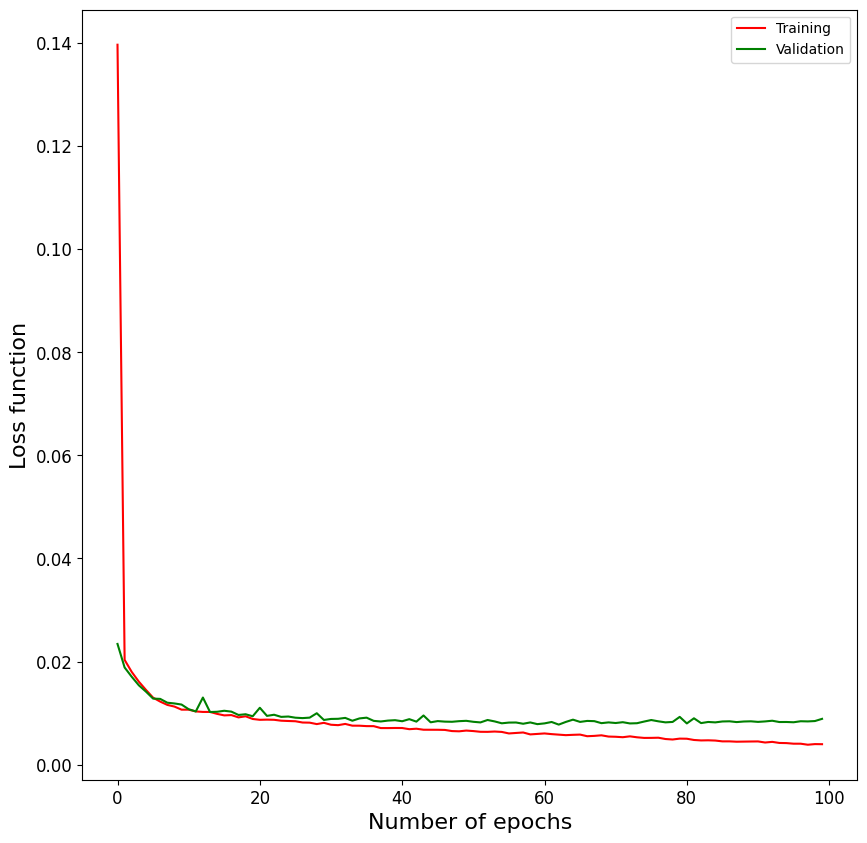

In [28]:
plot_loss(N_epochs_1, train_loss_1, eval_loss_1)

In [29]:
predictions_1 = []
targets_1 = []
test_loss_1 = []

with torch.no_grad():
  model_1.eval()
  for features,label in test_loader:
    src_tensor, lengths = features
    features = (src_tensor.to(device), lengths) #Move only the features on GPU, and create a tuple as the forward has it as an input
    label = label.to(device)
    output = model_1(features)
    loss = loss_1(output,label)
    test_loss_1.append(loss.item())

    predictions_1.append(output.cpu())
    targets_1.append(label.cpu())

pred_1 = torch.cat(predictions_1, dim=0).numpy()
real_1 = torch.cat(targets_1, dim=0).numpy()

avrg_test_loss_1 = np.mean(test_loss_1)

print(f'Average test loss: {avrg_test_loss_1:.4f}')

Average test loss: 0.0085


In [30]:
denorm_predictions_x = denormalize(pred_1[:,0], range_x_te)  # Denormalize predictions
denorm_predictions_y = denormalize(pred_1[:,1], range_y_te)  # Denormalize predictions
denorm_predictions_1 = np.column_stack((denorm_predictions_x, denorm_predictions_y))
denorm_true_labels_x = denormalize(real_1[:,0], range_x_te)  # Denormalize true labels
denorm_true_labels_y = denormalize(real_1[:,1], range_y_te)  # Denormalize true labels
denorm_true_labels_1 = np.column_stack((denorm_true_labels_x, denorm_true_labels_y))

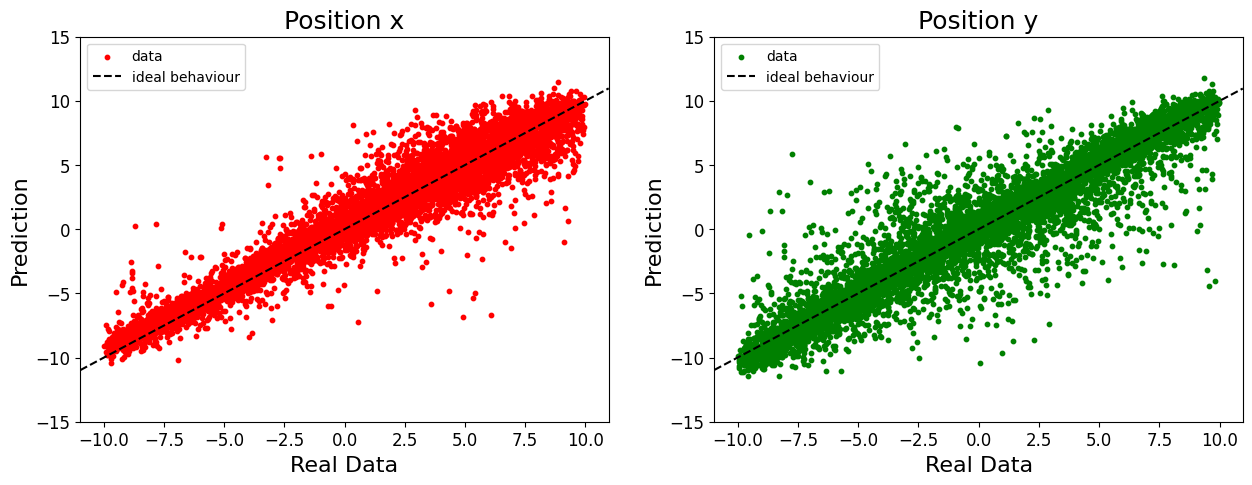

In [31]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))
ax = ax.flatten()

ax[0].set_ylim(-15,15)
ax[1].set_ylim(-15,15)

ax[0].set_xlabel('Real Data')
ax[0].set_ylabel('Prediction')
ax[0].set_title('Position x')
ax[0].scatter(denorm_true_labels_1[:,0],denorm_predictions_1[:,0], color = 'red', s = 10, label = 'data')
ax[0].axline((denorm_true_labels_1[:,0].min(), denorm_true_labels_1[:,0].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[0].legend(fontsize = 10)

ax[1].set_xlabel('Real Data')
ax[1].set_ylabel('Prediction')
ax[1].set_title('Position y')
ax[1].scatter(denorm_true_labels_1[:,1],denorm_predictions_1[:,1], color = 'green', s = 10, label = 'data')
ax[1].axline((denorm_true_labels_1[:,1].min(), denorm_true_labels_1[:,1].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[1].legend(fontsize = 10)

plt.show()

In [32]:
residual_x = denorm_true_labels_1[:,0] - denorm_predictions_1[:,0]
residual_y = denorm_true_labels_1[:,1] - denorm_predictions_1[:,1]

mean_x = np.mean(residual_x)
std_x = np.std(residual_x)
mean_y = np.mean(residual_y)
std_y = np.std(residual_y)

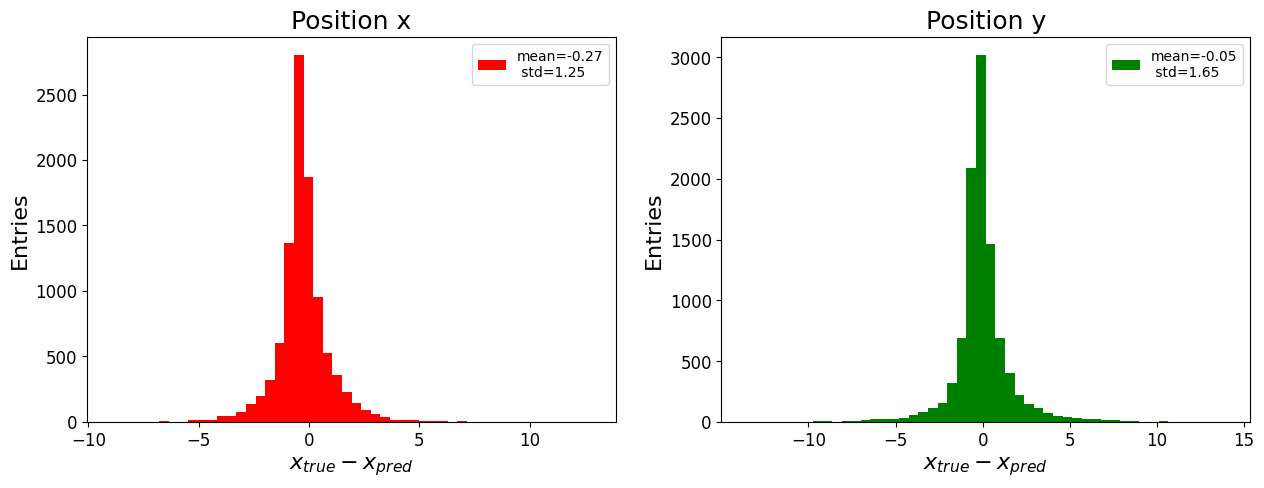

In [33]:
fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))
ax = ax.flatten()

ax[0].set_xlabel(r'$x_{true}-x_{pred}$')
ax[0].set_ylabel('Entries')
ax[0].set_title('Position x')
ax[0].hist(residual_x, color = 'red', bins = 50, label = f'mean={mean_x:.2f}\n std={std_x:.2f}')
ax[0].legend(fontsize = 10)

ax[1].set_xlabel(r'$x_{true}-x_{pred}$')
ax[1].set_ylabel('Entries')
ax[1].set_title('Position y')
ax[1].hist(residual_y, color = 'green', bins=50, label = f'mean={mean_y:.2f}\n std={std_y:.2f}')
ax[1].legend(fontsize = 10)

plt.show()

# Error estimation coupling the transformer based model to normalizing flows

In this architecture, the Transformer-based encoder is used to deduce the conditioning parameters of a Normalizing Flow, which models the underlying probability density function of the neutrino hit positions. To achieve this, the encoder's output dimension is strictly matched to the number of parameters required by the flow. As loss function a negative log likelihood is chosen. Once the target distribution is constructed, the best spatial prediction is extracted as the mean of the distribution, while the predictive uncertainty is explicitly quantified by its standard deviation.

In [34]:
def nf_loss(input, batch_labels, model):
    """
    Computes the loss for a normalizing flow model. Here already the predictions of the model (log_pdf) are computed, no need to use forward function for training,
    in this case the forward is used only to predict parameters but in the training what counts is the value of the PDF, the neural network is not predicting the labels.

    Parameters
    ----------
    input : torch.Tensor
        The input data of the model.
    batch_labels : torch.Tensor
        The labels corresponding to the input data.
    model : torch.nn.Module
        The normalizing flow model used for evaluation.
    Returns
    -------
    torch.Tensor
        The computed loss value.
    """
    log_pdfs = model.log_pdf_evaluation(batch_labels, input) # get the probability of the labels given the input data
    loss = -log_pdfs.mean() # take the negative mean of the log probabilities
    return loss

In [35]:
fp64_on_cpu = False

In [36]:
class CombinedModel(nn.Module):
    """
    A combined model that integrates a normalizing flow with a Transformer encoder.
    """

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        super().__init__()

        # Setup the normalizing flow...
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
            opt_dict["t"]["cov_type"] = "diagonal"
            flow_defs = "t"
        elif (nf_type == "full_gaussian"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "t"
        elif (nf_type == "full_flow"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "gggt"
        else:
            raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        self.pdf = jammy_flows.pdf("e2", flow_defs, options_overwrite=opt_dict,
                                   amortize_everything=True, amortization_mlp_use_custom_mode=True)

        num_flow_parameters = self.pdf.total_number_amortizable_params
        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        # Pass named arguments for better robustness and clarity
        self.encoder = encoder(embedding_dim=128, output_dim=num_flow_parameters)


    def log_pdf_evaluation(self, target_labels, input_data):
        latent_intermediate = self.encoder(input_data)

        if (self.nf_type == "full_flow"):
            if fp64_on_cpu:
                latent_intermediate = latent_intermediate.cpu().to(torch.float64)
                target_labels = target_labels.cpu().to(torch.float64)
            else:
                latent_intermediate = latent_intermediate.to(torch.float64)
                target_labels = target_labels.to(torch.float64)

        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf


    def sample(self, flow_params, samplesize_per_batchitem=1000):
        if (self.nf_type == "full_flow"):
            if fp64_on_cpu:
                flow_params = flow_params.cpu().to(torch.float64)
            else:
                flow_params = flow_params.to(torch.float64)

        batch_size = flow_params.shape[0]
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
            samplesize_per_batchitem, dim=0), allow_gradients=False)

        reshaped_samples = repeated_samples[:, None, :].view(
            batch_size, samplesize_per_batchitem, -1)

        return reshaped_samples


    def forward(self, input_data, samplesize_per_batchitem=1000):
        flow_params = self.encoder(input_data)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        means = samples.mean(dim=1)
        std_deviations = samples.std(dim=1)

        return torch.cat([means, std_deviations], dim=1)


    def visualize_pdf(self, input_data, filename, samplesize=1000, batch_index=0, truth=None):

        src, lengths = input_data

        # Calculate the start and end indices for the desired batch_index
        start_idx = sum(lengths[:batch_index])
        end_idx = start_idx + lengths[batch_index]

        # Extract the specific hits for the selected event
        single_src = src[start_idx:end_idx]
        single_length = [lengths[batch_index]]

        # Reconstruct the tuple to simulate a batch size of 1
        input_bitem = (single_src, single_length)

        flow_params = self.encoder(input_bitem)

        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)

        samples = samples.squeeze(0)

        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(2, 1, figsize = (10,10))
        for dim_ind in range(2):
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                 bins=50, alpha=0.5, label="density based on samples")

            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green",
                                 label="Gaussian approximation")

            if (truth is not None):
                # Handle the target whether it is a scalar tensor or a standard array/float
                true_value = truth[dim_ind].item() if hasattr(truth[dim_ind], 'item') else truth[dim_ind]
                axdict[dim_ind].axvline(
                    true_value, color="red", label="true value")

            if (dim_ind == 0):
                axdict[dim_ind].legend()

        plt.savefig(filename)
        plt.close(fig)

In [37]:
# Model selection
model_choice = 'CombinedModel'

if model_choice == 'CombinedModel':
    model_2 = CombinedModel(TransformerEncoder,"full_flow")
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model_2.to(device)

The normalizing flow has  197  parameters...


/tmp/ipykernel_1314/2253323813.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


CombinedModel(
  (pdf): pdf(
    (layer_list): ModuleList(
      (0): ModuleList(
        (0-2): 3 x gf_block()
        (3): mvn_block()
      )
    )
    (mlp_predictors): ModuleList(
      (0): None
    )
  )
  (encoder): TransformerEncoder(
    (input_embedding): Linear(in_features=3, out_features=128, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.02, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.02, inplace=False)
          (dropout2

In [38]:
N_epochs_2 = 100
learning_rate_2 = 0.0005

In [39]:
optimizer_2 = optim.Adam(model_2.parameters(), lr = learning_rate_2)

In [40]:
from tqdm import tqdm

train_loss_2 = []
eval_loss_2 = []

#-------Training-------
for epoch in range(N_epochs_2):
    model_2.train()
    loss_val = []

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{N_epochs_2}]") # Progress bar accepted by github rendering tools

    for features, label in loop:
        src_tensor, lengths = features
        features = (src_tensor.to(device), lengths) #Move only the features on GPU, and create a tuple as the forward has it as an input
        label = label.to(device)

        loss = nf_loss(features, label, model_2) #loss computation
        loss_val.append(loss.item())

        optimizer_2.zero_grad() #clean the gradients computed at previous iteration
        loss.backward() #backpropagation
        optimizer_2.step() #weights update

        # Update progress bar
        loop.set_postfix(loss=loss.item())

    train_loss_2.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
    with torch.no_grad():
        model_2.eval()
        loss_val = []
        for features, label in val_loader:
            src_tensor, lengths = features
            features = (src_tensor.to(device), lengths) #Move only the features on GPU, and create a tuple as the forward has it as an input
            label = label.to(device)

            loss = nf_loss(features, label, model_2)
            loss_val.append(loss.item())

        eval_loss_2.append(np.mean(loss_val))

#------------------------

Epoch [100/100]: 100%|██████████| 79/79 [00:11<00:00,  6.94it/s, loss=-3.92]


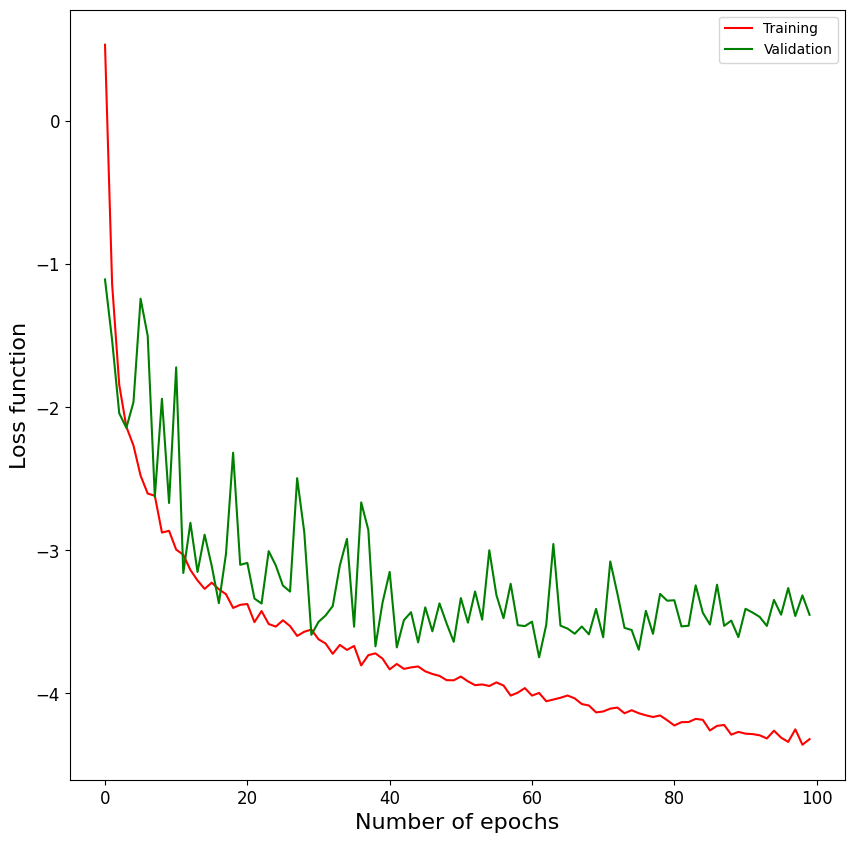

In [41]:
plot_loss(N_epochs_2, train_loss_2, eval_loss_2)

In [42]:
predictions_2 = []
labels_2 = []
test_loss_2 = []

with torch.no_grad():
  model_2.eval()
  for features,label in test_loader:
    src_tensor, lengths = features
    features = (src_tensor.to(device), lengths)
    label = label.to(device)
    pred = model_2(features) #return mean and std of the predicted distributions for every label through sampling
    loss = nf_loss(features,label,model_2)
    test_loss_2.append(loss.item())
    predictions_2.append(pred.cpu().numpy())
    labels_2.append(label.cpu())

avrg_test_loss_2 = np.mean(test_loss_2)
real_2 = torch.cat(labels_2, dim=0).numpy()
pred_2 = np.concatenate(predictions_2, axis=0)

print(f'Average test loss: {avrg_test_loss_2:.4f}')

Average test loss: -3.3792


In [43]:
denorm_predictions_x_2 = denormalize(pred_2[:,0], range_x_te)  # Denormalize predictions
denorm_predictions_y_2 = denormalize(pred_2[:,1], range_y_te)  # Denormalize predictions
denorm_predictions_2 = np.column_stack((denorm_predictions_x_2, denorm_predictions_y_2))
denorm_true_labels_x_2 = denormalize(real_2[:,0], range_x_te)  # Denormalize true labels
denorm_true_labels_y_2 = denormalize(real_2[:,1], range_y_te)  # Denormalize true labels
denorm_true_labels_2 = np.column_stack((denorm_true_labels_x_2, denorm_true_labels_y_2))
denorm_std_x_2 = denormalize_std(pred_2[:,2], range_x_te) #Denormalize standard deviation, as the model predicts the logarithm to get the std the exponential must be computed
denorm_std_y_2 = denormalize_std(pred_2[:,3], range_y_te)
denorm_std_2 = np.column_stack((denorm_std_x_2, denorm_std_y_2))

In [44]:
labels_name = ['Position x', 'Position y']
colors = ['red', 'green']

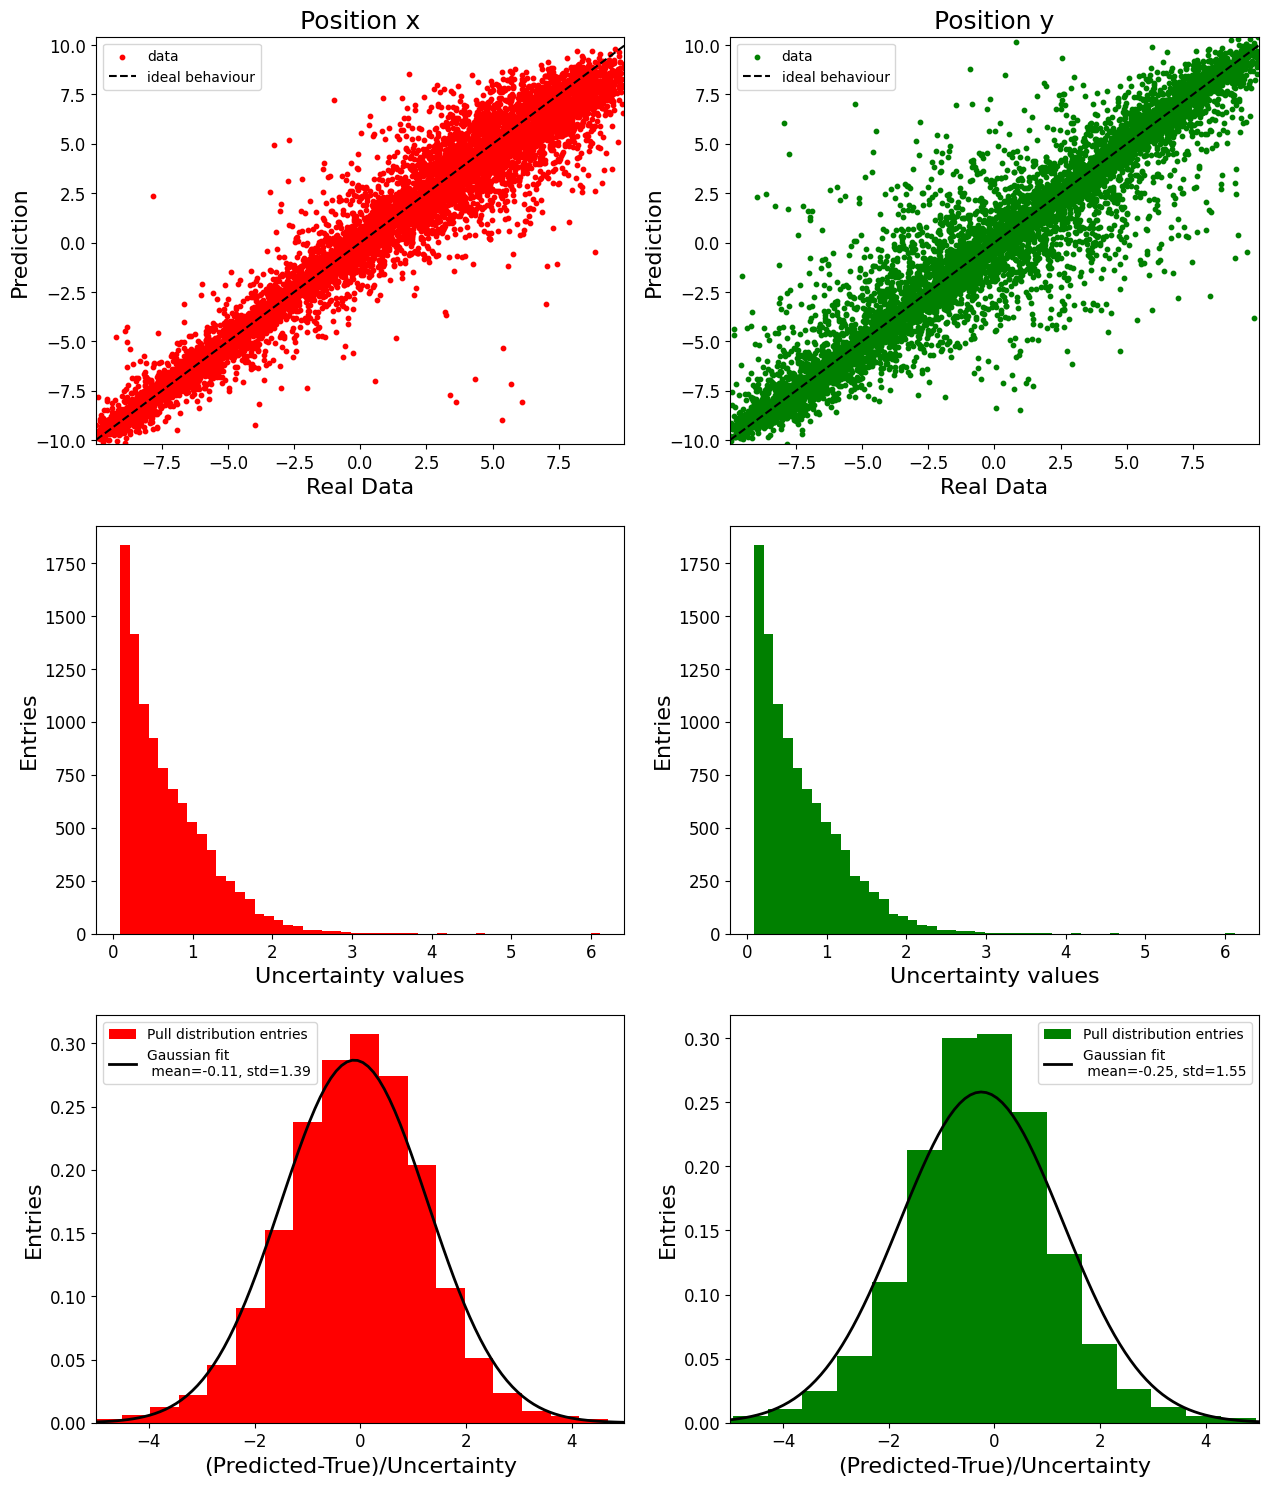

In [45]:
plot_results(denorm_true_labels_2, denorm_predictions_2, labels_name, denorm_std_2, colors)

In [46]:
DATA_PATH = '/content/drive/My Drive/Advanced_deep_learning/Exercise_8/'

In [47]:
import random

model_2.eval()
with torch.no_grad():

    features, label = next(iter(test_loader)) #Make the loader an iterable and extract the first available element

    src_tensor, lengths = features
    features = (src_tensor.to(device), lengths)
    label = label.to(device)

    #Choose three different indexes to pick three random batch elements
    batch_size = len(lengths)
    random_indices = random.sample(range(batch_size), k=3)

    # Loop on indeces and visualize the Predicted PDFs
    for idx in random_indices:
        filename = f"{DATA_PATH}full_flow_{idx}.png"

        model_2.visualize_pdf(
            input_data=features,
            filename=filename,
            samplesize=2000,
            batch_index=idx,
            truth=label[idx]
        )